# Spontaneous emission of TLS: TCP socket

Here, we introduce the two-level system (TLS) spontaneous emission tutorial using `maxwelllink.Molecule` and a TCP socket.

## 1. Setting up the socket communication layer

Using the TCP socket requires setting the `hostname` and `port number`. On a local machine, we can use the helper function `get_available_host_port()` from **MaxwellLink** to obtain these two pieces of information. Then, we initialize a `SocketHub` instance to provide the socket communication in **MaxwellLink**.

In [1]:
import numpy as np
import maxwelllink as mxl
from maxwelllink import sockets as mxs

try:
    import meep as mp
except ImportError as exc:  
    raise RuntimeError(
        "Meep is required for this tutorial."
        "Install via conda: conda install -c conda-forge pymeep=*=mpi_mpich_*"
    ) from exc

host, port = mxs.get_available_host_port()
hub = mxl.SocketHub(host=host, port=port, timeout=10.0, latency=1e-5)

print(f"SocketHub listening on {host}:{port}")


SocketHub listening on 127.0.0.1:59062


Before the simulation, users can understand the units system in MEEP with the following built-in function:

In [2]:
# or use: mxl.meep_units_helper(length_units_nm=2.9979E+01)
mxl.meep_units_helper(time_units_fs=0.1)

Now let's take a moment to understand the Meep unit system based on your provided units:
Given that you have specified:
- Time unit: 0.1 fs
By further assuming the MEEP simulation resolution is 10 pixels per length unit, we can derive the following Meep units:


 ######### MaxwellLink Units Helper #########
 MEEP uses its own units system, which is based on the speed of light in vacuum (c=1), 
 the permittivity of free space (epsilon_0=1), and the permeability of free space (mu_0=1). 
 To couple MEEP with molecular dynamics, we set [c] = [epsilon_0] = [mu_0] = [hbar] = 1. 
 By further defining the time unit or length unit, we can fix the units system of MEEP (mu).

 - Time [t]: 1 mu = 1.0000E-01 fs = 4.1341E+00 a.u.
 - Length [x]: 1 mu = 2.9979E+01 nm
 - EM wavelength of 1 mu, angular frequency omega = 2pi mu = 4.1375E+01 eV = 3.3371E+05 cm-1 = 1.5205E+00 a.u.
 - Note that sources and dielectrics defined in MEEP use rotational frequency (f=omega/2pi), 
 - so probabably we need covert 1

## 2. Bind Molecule and EM solver to the SocketHub

Then, we create a `Molecule` instance to define the information of this molecule in the EM simulation environment, including the `center`, `size`, `sigma` (width of the molecular polarization distribution), and `dimensions`. 

We also need to setup the EM solver (**MEEP**) using `mxl.MeepSimulation`. This class is a wrapper of the `meep.Simulation` object with extended parameters for **MaxwellLink**.

In [3]:
molecule = mxl.Molecule(
    hub=hub,
    center=mp.Vector3(0, 0, 0),
    size=mp.Vector3(1, 1, 1),
    sigma=0.1,
    dimensions=2,
)

sim = mxl.MeepSimulation(
    hub=hub,
    molecules=[molecule],
    cell_size=mp.Vector3(8, 8, 0),
    boundary_layers=[mp.PML(3.0)],
    resolution=10,
    # fix a units system 
    time_units_fs=0.1,
)


[Init Molecule] Under socket mode, registered molecule with ID 0


 ######### MaxwellLink Units Helper #########
 MEEP uses its own units system, which is based on the speed of light in vacuum (c=1), 
 the permittivity of free space (epsilon_0=1), and the permeability of free space (mu_0=1). 
 To couple MEEP with molecular dynamics, we set [c] = [epsilon_0] = [mu_0] = [hbar] = 1. 
 By further defining the time unit or length unit, we can fix the units system of MEEP (mu).

 - Time [t]: 1 mu = 1.0000E-01 fs = 4.1341E+00 a.u.
 - Length [x]: 1 mu = 2.9979E+01 nm
 - EM wavelength of 1 mu, angular frequency omega = 2pi mu = 4.1375E+01 eV = 3.3371E+05 cm-1 = 1.5205E+00 a.u.
 - Note that sources and dielectrics defined in MEEP use rotational frequency (f=omega/2pi), 
 - so probabably we need covert 1 eV photon energy to rotational frequency f = 2.4169E-02 mu
 - Electric field [E]: 1 mu = 6.6486E+07 V/m = 1.2930E-04 a.u.

 Given the simulation resolution = 10,
 - FDTD dt = 5.0000E-02 mu (0.5/r

## 3. Python way to launch `mxl_driver` on a separate terminal

Generally, using the Socket Interface requires launching the EM simulation in one terminal and then starting the molecular driver simulation in a separate terminal. To avoid opening a second terminal, below we introduce a Python helper function `launch_tls_driver(...)`, which will launch `mxl_driver` from Python (so we can stay within this notebook to finish this tutorial).

Here, we set the TLS starting at the initial excited-state population of 1e-4.

Immediately after launching this driver in the background, we run the simulation using `sim.run(...)`. This function is a wrapper of the `meep.Simulation.run(...)` function, which can accept user-defined step functions.

In [4]:
import shlex
import shutil
import subprocess
import time


def launch_tls_driver(host: str, port: int, sleep_time: float = 0.5):
    executable = shutil.which('mxl_driver')
    if executable is None:
        raise RuntimeError('mxl_driver executable not found in PATH.')
    cmd = (
        f"{executable} --model tls --address {host} --port {port}"
        f' --param "omega=0.242, mu12=187, orientation=2, pe_initial=1e-4"'
    )
    print('Launching TLS driver via subprocess...')
    print('If you prefer to run it manually, execute:')
    print('  ' + cmd)
    argv = shlex.split(cmd)
    proc = subprocess.Popen(argv)
    time.sleep(sleep_time)
    return proc

launch_tls_driver(host, port)

sim.run(until=400)

Launching TLS driver via subprocess...
If you prefer to run it manually, execute:
  /Users/taoli/miniforge3/envs/mxl/bin/mxl_driver --model tls --address 127.0.0.1 --port 59062 --param "omega=0.242, mu12=187, orientation=2, pe_initial=1e-4"
-----------
Initializing structure...
time for choose_chunkdivision = 0.000616074 s
Working in 2D dimensions.
Computational cell is 8 x 8 x 0 with resolution 10
time for set_epsilon = 0.00299597 s
-----------
[SocketHub][initialization] Time step in atomic units:  CONNECTED: mol 0 <- 127.0.0.1:59065
0.20670686667500004
[initialization] Assigned a molecular ID: 0
init TLSModel with dt = 0.206707 a.u., molecule ID = 0
[initialization] Finished initialization for molecular ID: 0
Meep progress: 379.15000000000003/400.0 = 94.8% done in 4.0s, 0.2s to go
on time step 7592 (time=379.6), 0.000526919 s/step
run 0 finished at t = 400.0 (8000 timesteps)
Received STOP, exiting
[SocketHub] DISCONNECTED: mol 0 from 127.0.0.1:59065


## 4. Retrieve molecular simulation data

After the simulation, we can retrieve molecular simulation data from `molecule.extra`, a Python dictionary which stores the molecular information sent from the driver code at each step of the simulation.

In [5]:
# users can also use molecule.additional_data_history to access the time-resolved data recorded during the simulation, 
# population = np.array([entry["Pe"] for entry in molecule.additional_data_history])
# time_au = np.array([entry["time_au"] for entry in molecule.additional_data_history])
# but here we demonstrate the use of molecule.extra which is more convenient for post-processing and plotting. 

population = molecule.extra["Pe"]
time_au = molecule.extra["time_au"]

print(f"Collected {population.size} samples.")

Collected 8001 samples.


## 5. Compare with the Analytical Golden-Rule Decay

Finally, we can compare this numerical simulation with analytical golden-rule rate calculations, with the 2D  spontaneus emission in vacuum as:

$$
k_{\rm {FGR}} = \frac{|\mu_{12}|^2 \omega^2}{2\hbar\epsilon_0 c^2}
$$

The corresponding TLS excited-state population decay dynamics obey:

$$
P_{\rm e}^{\rm {QM}}(t) = P_{\rm e}(0) e^{-k_{\rm{FGR}} t}
$$

When the EM field is described entirely classically, more than half a century ago, Jaynes and collaborators (https://ieeexplore.ieee.org/document/1443594) calculated the semiclassical spontaneous emission rate. More recently, we have also reproduced this semiclassical excited-state population decay (https://doi.org/10.1103/PhysRevA.97.032105):

$$
P_{\rm e}^{\rm {sc}}(t) = \frac{e^{-k_{\rm{FGR}} t}}{e^{-k_{\rm{FGR}} t} + \frac{1 - P_{\rm e}(0) }{P_{\rm e}(0) }}
$$

When $P_{\rm e}(0)\rightarrow 0$, the semiclassical decay dynamics exactly agree with the quantum correspondance $P_{\rm e}^{\rm {QM}}(t)$.

As shown below, using $P_{\rm e}(0)= 10^{-4}$, our semiclassical simulation exactly reproduces the quantum golden-rule decay.

std_dev=2.012e-03, max_abs_diff=7.928e-03


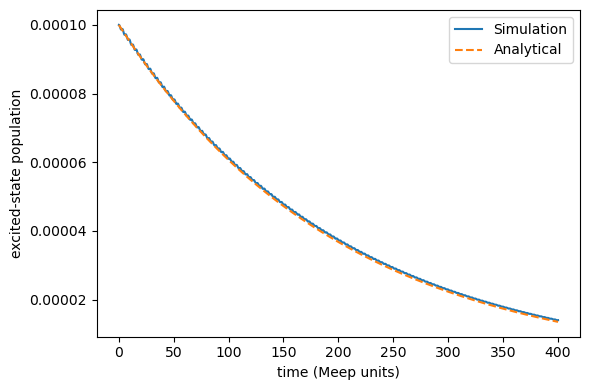

In [6]:
time_fs = time_au * 0.02418884254
time_meep = time_fs / 0.1
initial = population[0]
dipole_moment = 0.1 # meep units of mu12
frequency = 1.0 # meep units of omega

# analytical golden-rule decay rate
gamma = dipole_moment**2 * frequency**2 / 2.0

# simple exponential decay reference
reference = initial * np.exp(-time_meep * gamma)

# below is a more accurate reference which works under any initial population
#reference = np.exp(-time_meep * gamma) / (
#    np.exp(-time_meep * gamma) + (1.0 - initial) / initial
#)

std_rel = np.std(population - reference) / initial
max_rel = np.max(np.abs(population - reference)) / initial
print(f"std_dev={std_rel:.3e}, max_abs_diff={max_rel:.3e}")

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(time_meep, population, label="Simulation")
plt.plot(time_meep, reference, label="Analytical", linestyle="--")
plt.xlabel("time (Meep units)")
plt.ylabel("excited-state population")
plt.legend()
plt.tight_layout()
plt.show()
